NEPSE Volatility Analysis
Adapted from starter notebook to match actual data:
  - File : nepse_index_history.csv
  - Columns: Date, Open, High, Low, Close, Change, Percent_Change, Turnover
 
Run from project root:
    pip install arch statsmodels matplotlib
    python NEPSE_Volatility_Analysis.py



In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
 
plt.style.use("seaborn-v0_8-whitegrid")
 
# ── CONFIG ────────────────────────────────────────────────────────────────
BASE           = Path(__file__).parent if "__file__" in dir() else Path.cwd()
DATA_FILE      = BASE / "nepse_index_history.csv"
OUTPUT_CSV     = BASE / "nepse_volatility_analysis.csv"
OUTPUT_PNG     = BASE / "nepse_volatility_analysis.png"
 
ROLLING_WINDOW      = 15
ANNUALIZATION_DAYS  = 252
 

# 1. LOAD & CLEAN 

In [3]:
df = pd.read_csv(DATA_FILE, parse_dates=["Date"])
df = df.sort_values("Date").set_index("Date")
 
# Drop the pre-2016 rows where OHLC are identical (index-only era)
mask_real = ~(
    (df["Open"] == df["High"]) &
    (df["High"] == df["Low"]) &
    (df["Low"] == df["Close"])
)
df_full = df[mask_real].copy()   # 2016-06-06 onwards
 
print(f"Loaded {len(df):,} total rows")
print(f"Using  {len(df_full):,} rows with real OHLC (post-2016)")
print(f"Date range: {df_full.index.min().date()} → {df_full.index.max().date()}")

Loaded 3,759 total rows
Using  2,291 rows with real OHLC (post-2016)
Date range: 2016-06-06 → 2026-06-12


## 2. LOG RETURNS


In [4]:
df["log_return"]     = np.log(df["Close"] / df["Close"].shift(1))
df["log_return_pct"] = df["log_return"] * 100

## 3. ROLLING HISTORICAL VOLATILITY (15-day)


In [5]:
df["rolling_vol_15d_daily_pct"]      = df["log_return"].rolling(ROLLING_WINDOW).std() * 100
df["rolling_vol_15d_annualized_pct"] = df["rolling_vol_15d_daily_pct"] * np.sqrt(ANNUALIZATION_DAYS)

## 4. GARCH(1,1)


In [7]:
returns_pct = df["log_return_pct"].dropna()
 
garch_model_fit = arch_model(
    returns_pct,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal",
    rescale=False,
)
 
garch_result = garch_model_fit.fit(disp="off")
print("\n" + "=" * 60)
print(garch_result.summary())
 
df.loc[returns_pct.index, "garch_vol_daily_pct"]      = garch_result.conditional_volatility
df["garch_vol_annualized_pct"] = df["garch_vol_daily_pct"] * np.sqrt(ANNUALIZATION_DAYS)


                     Constant Mean - GARCH Model Results                      
Dep. Variable:         log_return_pct   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -5859.80
Distribution:                  Normal   AIC:                           11727.6
Method:            Maximum Likelihood   BIC:                           11752.5
                                        No. Observations:                 3758
Date:                Thu, Jun 25 2026   Df Residuals:                     3757
Time:                        13:46:01   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0200  1.975e-02      1.012      0.311

## 5. PARKINSON RANGE VOLATILITY (post-2016 only)


In [8]:
df_full["log_hl"]          = np.log(df_full["High"] / df_full["Low"])
df_full["parkinson_daily"]  = np.sqrt(df_full["log_hl"] ** 2 / (4 * np.log(2)))
df_full["parkinson_vol_annualized_pct"] = (
    df_full["parkinson_daily"].rolling(ROLLING_WINDOW).mean() * np.sqrt(ANNUALIZATION_DAYS) * 100
)
 
# Merge back
df = df.join(df_full[["parkinson_vol_annualized_pct"]], how="left")

## 6. Save CSV



In [9]:
analysis_columns = [
    "Close",
    "log_return",
    "log_return_pct",
    "rolling_vol_15d_daily_pct",
    "rolling_vol_15d_annualized_pct",
    "garch_vol_daily_pct",
    "garch_vol_annualized_pct",
    "parkinson_vol_annualized_pct",
]
df[analysis_columns].to_csv(OUTPUT_CSV)
print(f"\nSaved processed data → {OUTPUT_CSV}")


Saved processed data → /Users/anamgiri/Desktop/nepal-stock-market-research/nepse_volatility_analysis.csv


## 7. PLOT


Saved chart      → /Users/anamgiri/Desktop/nepal-stock-market-research/nepse_volatility_analysis.png


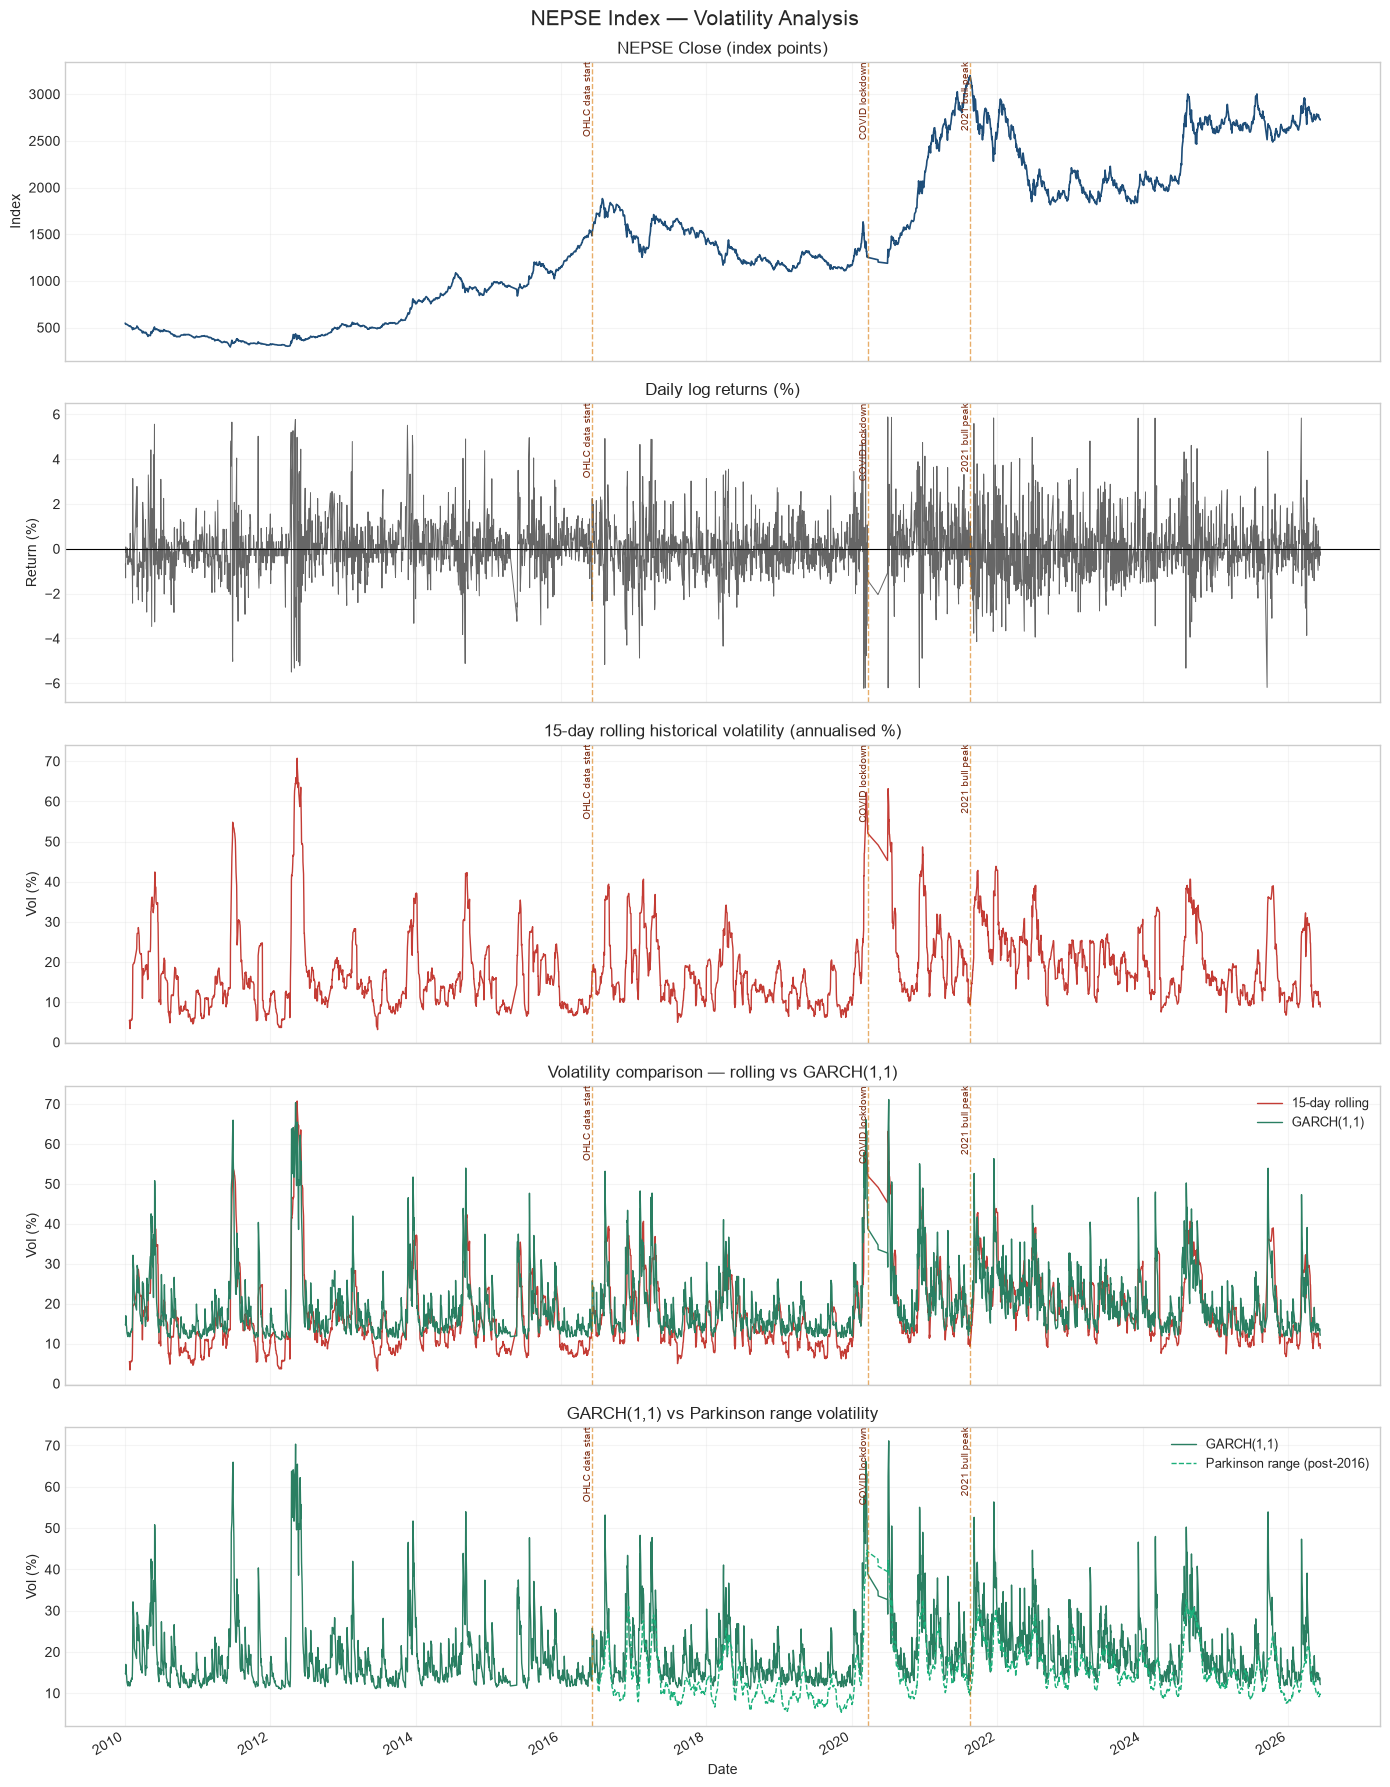

In [10]:
BLUE  = "#1f4e79"
GRAY  = "#666666"
RED   = "#c43c35"
GREEN = "#2a7f62"
TEAL  = "#1baf7a"
 
fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)
fig.suptitle("NEPSE Index — Volatility Analysis", fontsize=15, fontweight="normal", y=0.99)
 
# Panel 1: Index
df["Close"].plot(ax=axes[0], color=BLUE, linewidth=1.2)
axes[0].set_title("NEPSE Close (index points)")
axes[0].set_ylabel("Index")
 
# Panel 2: Log returns
df["log_return_pct"].plot(ax=axes[1], color=GRAY, linewidth=0.7)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Daily log returns (%)")
axes[1].set_ylabel("Return (%)")
 
# Panel 3: Rolling volatility
df["rolling_vol_15d_annualized_pct"].plot(ax=axes[2], color=RED, linewidth=1.0)
axes[2].set_title("15-day rolling historical volatility (annualised %)")
axes[2].set_ylabel("Vol (%)")
 
# Panel 4: GARCH vs rolling
df["rolling_vol_15d_annualized_pct"].plot(
    ax=axes[3], label="15-day rolling", color=RED, linewidth=1.0
)
df["garch_vol_annualized_pct"].plot(
    ax=axes[3], label="GARCH(1,1)", color=GREEN, linewidth=1.0
)
axes[3].set_title("Volatility comparison — rolling vs GARCH(1,1)")
axes[3].set_ylabel("Vol (%)")
axes[3].legend(fontsize=9)
 
# Panel 5: GARCH vs Parkinson (post-2016)
df["garch_vol_annualized_pct"].plot(
    ax=axes[4], label="GARCH(1,1)", color=GREEN, linewidth=1.0
)
df["parkinson_vol_annualized_pct"].plot(
    ax=axes[4], label="Parkinson range (post-2016)", color=TEAL, linewidth=1.0, linestyle="--"
)
axes[4].set_title("GARCH(1,1) vs Parkinson range volatility")
axes[4].set_ylabel("Vol (%)")
axes[4].legend(fontsize=9)
 
# Event markers
events = {
    "COVID lockdown" : pd.Timestamp("2020-03-24"),
    "2021 bull peak" : pd.Timestamp("2021-08-18"),
    "OHLC data start": pd.Timestamp("2016-06-06"),
}
 
for ax in axes:
    ylim = ax.get_ylim()
    for label, event_date in events.items():
        ax.axvline(event_date, color="#d97706", linestyle="--", alpha=0.6, linewidth=1)
        ax.text(
            event_date, ylim[1], label,
            rotation=90, va="top", ha="right",
            fontsize=7.5, color="#7c2d12"
        )
    ax.grid(True, alpha=0.2)
 
fig.tight_layout()
fig.savefig(OUTPUT_PNG, dpi=180, bbox_inches="tight")
print(f"Saved chart      → {OUTPUT_PNG}")
plt.show()

## 8. SUMMARY STATS

In [11]:
print("\n" + "=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)
summary = df[[
    "log_return_pct",
    "rolling_vol_15d_annualized_pct",
    "garch_vol_annualized_pct",
    "parkinson_vol_annualized_pct",
]].describe().round(4)
print(summary)


SUMMARY STATISTICS
       log_return_pct  rolling_vol_15d_annualized_pct  \
count       3758.0000                       3744.0000   
mean           0.0427                         18.1121   
std            1.3185                          9.8136   
min           -6.2262                          3.1477   
25%           -0.6133                         11.2911   
50%           -0.0267                         15.6528   
75%            0.6208                         22.2569   
max            5.8847                         70.7463   

       garch_vol_annualized_pct  parkinson_vol_annualized_pct  
count                 3758.0000                     2277.0000  
mean                    19.5746                       15.1900  
std                      8.4607                        6.2271  
min                     10.9466                        5.3710  
25%                     13.9146                       10.7318  
50%                     16.8686                       13.9827  
75%               

In [12]:
# GARCH parameters
print("\nGARCH(1,1) parameters:")
params = garch_result.params
print(f"  omega (ω) : {params['omega']:.6f}")
print(f"  alpha (α) : {params['alpha[1]']:.4f}  ← shock sensitivity")
print(f"  beta  (β) : {params['beta[1]']:.4f}  ← volatility persistence")
print(f"  α + β     : {params['alpha[1]'] + params['beta[1]']:.4f}  ← close to 1 = high persistence")


GARCH(1,1) parameters:
  omega (ω) : 0.137904
  alpha (α) : 0.2359  ← shock sensitivity
  beta  (β) : 0.6963  ← volatility persistence
  α + β     : 0.9322  ← close to 1 = high persistence
